Saving Social_Network_Ads.csv to Social_Network_Ads (1).csv
Accuracy: 0.9125
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        52
           1       0.92      0.82      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.89      0.90        80
weighted avg       0.91      0.91      0.91        80



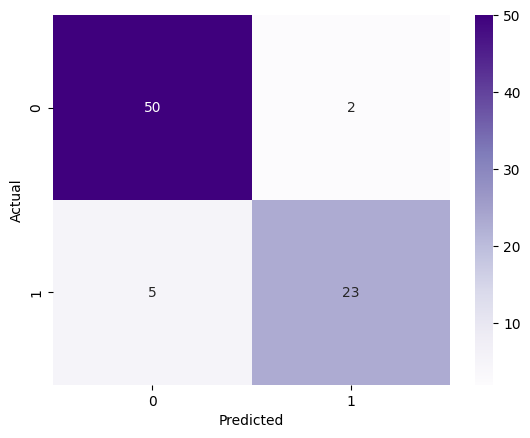

In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

X = df.drop('Purchased', axis=1)
y = df['Purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Saving Social_Network_Ads.csv to Social_Network_Ads (2).csv


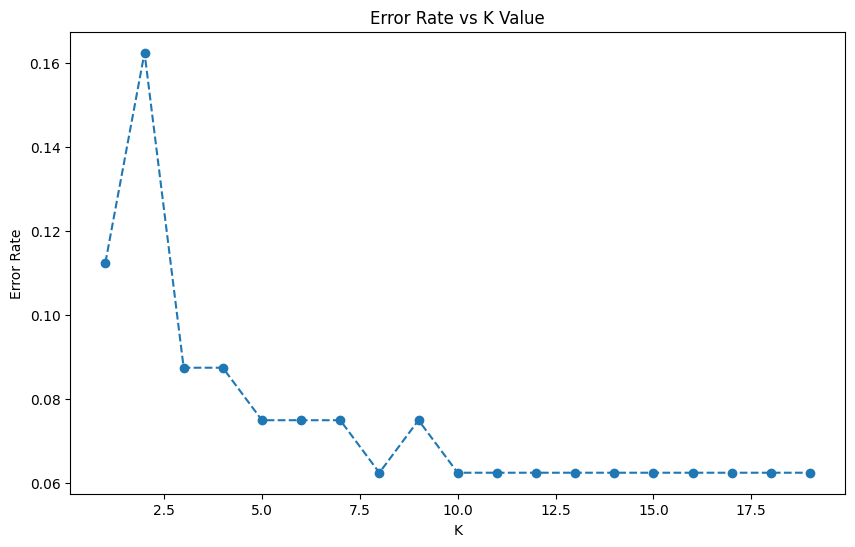

Optimal K: 8


In [5]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df = df.drop('User ID', axis=1)
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

X = df.drop('Purchased', axis=1)
y = df['Purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

error_rate = []

for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,20), error_rate, linestyle='dashed', marker='o')
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.show()

optimal_k = error_rate.index(min(error_rate)) + 1
print("Optimal K:", optimal_k)

Accuracy: 0.9375


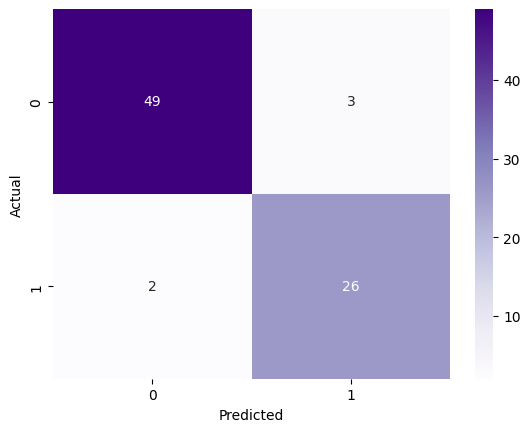

In [6]:
model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()